# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [1]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.3 MB/s eta 0:00:00
✅ Dependencies ready


In [2]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [3]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Keys are the string labels in your CSV; values are integers starting at 0.
# Add or remove entries to match your actual labels (2–4 labels supported).
#
# The example below is ILLUSTRATIVE ONLY (the r/nba taxonomy from the project
# page). DELETE it and use your own community's labels — submitting the
# example unchanged will not pass.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "dd":  0,   # ← Replace with your first label
    "speculation":  1,   # ← Replace with your second label
    "reaction":  2,   # ← Replace with your third label (remove if you have 2 labels)
    # "fourth_label": 3,  # ← Uncomment if you have a fourth label
}

# ── END TODO ──────────────────────────────────────────────────────────────

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'dd': 0, 'speculation': 1, 'reaction': 2}
Number of labels: 3


In [4]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving takemeter_data.csv to takemeter_data.csv
Uploaded: takemeter_data.csv


In [5]:
# @title
# Load and validate your dataset
import pandas as pd
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['text', 'label']
Total examples: 360

Label distribution:
label
reaction       163
dd             102
speculation     95
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [6]:
from sklearn.model_selection import train_test_split

# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 252 examples
Validation: 54 examples
Test: 54 examples

Train label distribution:
label
reaction       114
dd              71
speculation     67
Name: count, dtype: int64

Test label distribution:
label
reaction       24
dd             16
speculation    14
Name: count, dtype: int64


In [7]:
from transformers import AutoTokenizer, DataCollatorWithPadding
from datasets import Dataset

# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/252 [00:00<?, ? examples/s]

Map:   0%|          | 0/54 [00:00<?, ? examples/s]

Map:   0%|          | 0/54 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [8]:
from transformers import AutoModelForSequenceClassification

# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 3


In [9]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds),
            "f1_macro": f1_score(labels, preds, average="macro")}


In [10]:
from sklearn.utils.class_weight import compute_class_weight
import torch, numpy as np
classes = np.array(sorted(LABEL_MAP.values()))
class_weights = compute_class_weight("balanced", classes=classes, y=train_df["label_id"].values)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", dict(zip([ID_TO_LABEL[c] for c in classes], [round(w,2) for w in class_weights.tolist()])))

from torch import nn
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(outputs.logits.device))
        loss = loss_fct(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

Class weights: {'dd': 1.18, 'speculation': 1.25, 'reaction': 0.74}


In [11]:
from transformers import TrainingArguments, Trainer
from transformers import AutoModelForSequenceClassification

# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=6,          # was 3 — too few steps for the model to learn
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,            # was warmup_steps=50, which exceeded total steps (~48)
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=10,
    report_to="none",
)

trainer = trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.093325,1.048593,0.537037,0.491606
2,0.999189,0.965096,0.592593,0.555706
3,0.881131,0.891578,0.629630,0.517834
4,0.776430,0.842033,0.685185,0.616095
5,0.704888,0.812247,0.703704,0.651875
6,0.617818,0.810444,0.685185,0.631013


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [12]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.722

Per-class metrics (fine-tuned model):
              precision    recall  f1-score   support

          dd       0.79      0.94      0.86        16
 speculation       0.50      0.21      0.30        14
    reaction       0.72      0.88      0.79        24

    accuracy                           0.72        54
   macro avg       0.67      0.68      0.65        54
weighted avg       0.69      0.72      0.68        54



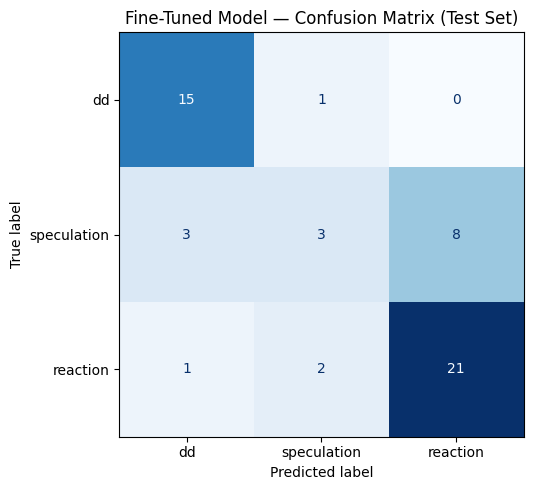

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [14]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 15 / 54

--- #1 ---
Text:      Regardless if the deadline is 2 years from tomorrow, the shares can't really go under $10 since there is insurance, the biggest risk is interest rate, but from my understanding there is an interest cl...
True:      dd
Predicted: speculation  (confidence: 0.41)

--- #2 ---
Text:      SLV must pump again

Silver has been beat down because of the pump from like January and then the fact that investments were transitioning away from the precious metals because there were better optio...
True:      speculation
Predicted: dd  (confidence: 0.41)

--- #3 ---
Text:      I actually joined the hedges and shorted the fuck out of $BBY because I think when markets open tomorrow it will be the end
True:      speculation
Predicted: reaction  (confidence: 0.60)

--- #4 ---
Text:      Th starbucks next to my house closed indefinitely due to lack of staff bankruptcy is imminent. Position: Nov 18 , 82.50 strike puts
True:      reaction
Predicted: speculati

---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [15]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [16]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Your prompt should:
#   1. Name your community and task
#   2. Define each label in plain language (copy from your planning.md)
#   3. Give one example post per label
#   4. Tell the model to output ONLY the label name — nothing else
#
# The model's response must match one of your label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────
# REPLACE the placeholders below with your actual prompt. As written, this
# skeleton will NOT classify correctly — you must fill it in.

SYSTEM_PROMPT = """
You are classifying posts from the r/wallstreetbets subreddit by the TYPE of discourse.
Assign each post to exactly one of these three categories.

dd: A structured, reasoned argument backed by specific, checkable evidence — financials, valuation, catalysts, guidance, option mechanics, historical data. You could argue with it on its merits.
Example: "Costco trades at ~42x forward earnings, priced for perfection. Core merchandise margins contracted three quarters in a row and membership income faces comp headwinds."

speculation: A confident directional call or trade thesis WITHOUT real supporting evidence. The reasoning is absent, vague, decorative, or vibes-based — even if it name-drops numbers or technical terms.
Example: "Once the US 10yr hits 4.20% the play is TSLA 400c 3 months out. You heard it here first."

reaction: An emotional or momentum expression — hype, celebration, panic, loss/gain posts, jokes, or venting. No claim is being argued.
Example: "Lmfao so many puts got bent over."

Respond with ONLY the label name (dd, speculation, or reaction).
Do not explain your reasoning.

Valid labels:
dd
speculation
reaction
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 1144 characters


In [17]:
import time

def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 54 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/54 complete...
  20/54 complete...
  30/54 complete...
  40/54 complete...
  50/54 complete...


In [18]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.778  (evaluated on 54/54 parseable responses)

Per-class metrics (baseline):
              precision    recall  f1-score   support

          dd       0.93      0.81      0.87        16
 speculation       0.60      0.64      0.62        14
    reaction       0.80      0.83      0.82        24

    accuracy                           0.78        54
   macro avg       0.78      0.76      0.77        54
weighted avg       0.79      0.78      0.78        54



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [19]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.778
Fine-tuned DistilBERT                  0.722
---------------------------------------------

Fine-tuning regression: 0.056

Use these numbers in your README evaluation report.


In [20]:
from sklearn.metrics import f1_score, classification_report

ft_macro_f1 = f1_score(ft_true_ids, ft_pred_ids, average="macro")
bl_macro_f1 = f1_score(bl_true_ids, bl_pred_ids, average="macro")

results = {
    "baseline_accuracy":   round(bl_accuracy, 4),
    "finetuned_accuracy":  round(ft_accuracy, 4),
    "baseline_macro_f1":   round(bl_macro_f1, 4),
    "finetuned_macro_f1":  round(ft_macro_f1, 4),
    "macro_f1_improvement": round(ft_macro_f1 - bl_macro_f1, 4),
    "finetuned_per_class": classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, output_dict=True, zero_division=0),
    "baseline_per_class":  classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, output_dict=True, zero_division=0),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download


In [23]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# save the model just trained in Section 3 — this is the source of truth now
trainer.save_model("takemeter-final")
tokenizer.save_pretrained("takemeter-final")
print("✅ saved trained model to takemeter-final\n")

# load it back under separate names so it can never clobber `model`
demo_model = AutoModelForSequenceClassification.from_pretrained("takemeter-final")
demo_tok   = AutoTokenizer.from_pretrained("takemeter-final")
demo_model.eval()

def classify(text):
    enc = demo_tok(text, truncation=True, max_length=256, return_tensors="pt").to(demo_model.device)
    with torch.no_grad():
        probs = torch.softmax(demo_model(**enc).logits, dim=-1)[0]
    p = probs.argmax().item()
    print(f"{text[:90]!r}\n   → {demo_model.config.id2label[p].upper()}  (confidence {probs[p]:.2f})\n")

classify("SOFI 5/15 calls: macro lotto or theta donation? Positions: 125x SOFI $16C 5/15 @ $0.09")
classify("Costco trades at ~42x forward earnings, priced for perfection. Margins contracted three quarters straight.")
classify("Thank God I had class. I was going to buy PUTS on $DOCU for ER")
classify("Upcoming Stock Market Drop Will Be Epic Fury. Fundamental Analysis: he wants oil high and the strait closed.")
classify("What do you guys think? I Think Bullish")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ saved trained model to takemeter-final



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

'SOFI 5/15 calls: macro lotto or theta donation? Positions: 125x SOFI $16C 5/15 @ $0.09'
   → REACTION  (confidence 0.40)

'Costco trades at ~42x forward earnings, priced for perfection. Margins contracted three qu'
   → DD  (confidence 0.42)

'Thank God I had class. I was going to buy PUTS on $DOCU for ER'
   → REACTION  (confidence 0.63)

'Upcoming Stock Market Drop Will Be Epic Fury. Fundamental Analysis: he wants oil high and '
   → SPECULATION  (confidence 0.47)

'What do you guys think? I Think Bullish'
   → REACTION  (confidence 0.65)

